# Sample Statistics: Population $\rightarrow$ Sample

Goal: start with a large population, take a random sample, and see how sample statistics estimate population statistics.

We will use a Poisson population, following the basic setup in Brunton's lecture.

In [85]:
import numpy as np
import matplotlib.pyplot as plt

# Large bimodal population
N = 100_000

# Half from one Gaussian, half from another
population = np.concatenate([
    rng.normal(loc=-2, scale=1.0, size=N // 2),
    rng.normal(loc= 3, scale=0.5, size=N // 2)
])

mu = np.mean(population)
sigma2 = np.var(population)

print(f"Population mean     = {mu:.3f}")
print(f"Population variance = {sigma2:.3f}")

Population mean     = 0.499
Population variance = 6.899


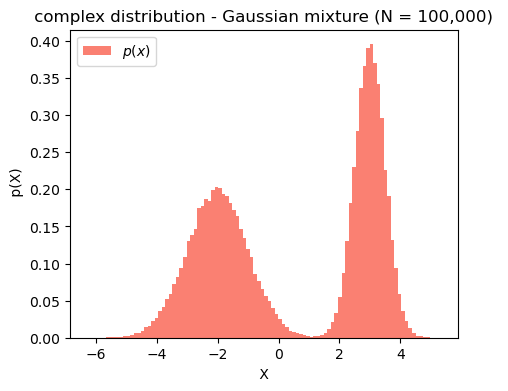

In [94]:
plt.figure(figsize=(5, 4))
plt.title(f" complex distribution - Gaussian mixture (N = 100,000) ")
plt.hist(population,bins=100,density=True,color='salmon',label=r"$p(x)$")
plt.xlabel(r" X ")
plt.ylabel(" p(X)")
plt.legend()
#plt.show()
plt.savefig('comp_dist.png',dpi=250)

## 1. Take one random sample

For a sample $X_1,\ldots,X_n$,

$$
\bar X=\frac{1}{n}\sum_{i=1}^n X_i,
\qquad
s^2=\frac{1}{n-1}\sum_{i=1}^n (X_i-\bar X)^2.
$$

How close are these to the population mean and variance?

In [97]:
n = 1000
sample = rng.choice(population, size=n, replace=False)

xbar = np.mean(sample)
s2 = np.var(sample, ddof=1)   # divide by n-1

print(f"Sample size         = {n}")
print(f"Sample mean         = {xbar:.3f}")
print(f"Sample variance     = {s2:.3f}")
print()
print(f"Population mean     = {mu:.3f}")
print(f"Population variance = {sigma2:.3f}")

Sample size         = 1000
Sample mean         = 0.440
Sample variance     = 7.080

Population mean     = 0.499
Population variance = 6.899


## 2. The sample mean is itself random

Take many different samples of the same size. Each sample gives a different $\bar X$.

Mean of sample means = 0.501
Population mean      = 0.499


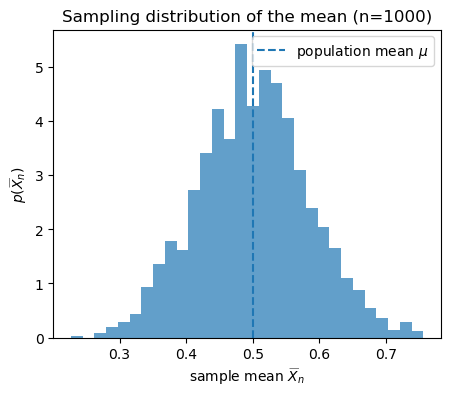

In [102]:
M = 2000 # Remember this M is different from the sample-size N.. 
sample_means = []

for _ in range(M):
    sample = rng.choice(population, size=n, replace=False)
    sample_means.append(np.mean(sample))

sample_means = np.array(sample_means)

plt.figure(figsize=(5, 4))
plt.hist(sample_means, bins=30, density=True, alpha=0.7)
plt.axvline(mu, linestyle="--", label=r"population mean $\mu$")
plt.xlabel(r"sample mean $\widebar{X}_n$")
plt.ylabel("$p(\widebar{X}_n)$")
plt.title(f"Sampling distribution of the mean (n={n})")
plt.legend()
#plt.show()
plt.savefig('CLT_emp.png',dpi=250)

print(f"Mean of sample means = {np.mean(sample_means):.3f}")
print(f"Population mean      = {mu:.3f}")

## 3. Larger samples give more stable estimates

The standard error of the sample mean is approximately

$$
\mathrm{SE}(\bar X)=\frac{\sigma}{\sqrt{n}}.
$$

So increasing $n$ should make the sample means less spread out.

In [91]:
for n in [10, 30, 100, 300, 3000]:
    means = [
        np.mean(rng.choice(population, size=n, replace=False))
        for _ in range(M)
    ]

    empirical_se = np.std(means)
    theory_se = np.std(population) / np.sqrt(n)
    error = np.abs(empirical_se - theory_se)

    print(
        f"n={n:3d} | empirical SD(x̄)={empirical_se:.3f} "
        f"| sigma/sqrt(n)={theory_se:.3f}" f"| error={error:.3f}"
    )

n= 10 | empirical SD(x̄)=0.824 | sigma/sqrt(n)=0.831| error=0.007
n= 30 | empirical SD(x̄)=0.490 | sigma/sqrt(n)=0.480| error=0.011
n=100 | empirical SD(x̄)=0.256 | sigma/sqrt(n)=0.263| error=0.007
n=300 | empirical SD(x̄)=0.153 | sigma/sqrt(n)=0.152| error=0.001
n=3000 | empirical SD(x̄)=0.048 | sigma/sqrt(n)=0.048| error=0.000


### Takeaway

- The **population** has fixed but usually unknown statistics.
- A **sample** gives estimates such as $\bar X$ and $s^2$.
- Different random samples give different estimates.
- $\bar X$ is centered near the population mean.
- Larger samples make $\bar X$ more stable: its spread decreases roughly as $1/\sqrt{n}$.